# Proyek Klasifikasi Gambar: [Fruits-360 Dataset]
- **Nama:** [Nero Caesar Suprobo]
- **Email:** [nerosuprobo@gmail.com]
- **ID Dicoding:** [nero_suprobo]

## Import Semua Packages/Library yang Digunakan

In [1]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

2026-05-11 14:49:29.397618: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778510969.672559      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778510969.751246      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778510970.438521      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778510970.438561      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778510970.438563      57 computation_placer.cc:177] computation placer alr

## Data Preparation

### Data Loading

In [2]:
base_path = '/kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360/Training'

os.listdir(base_path)

['Melon Piel de Sapo 1',
 'Dates 1',
 'Avocado Black 2',
 'Nectarine Flat 2',
 'Apple Crimson Snow 1',
 'Cherry Wax 2',
 'Onion Red 1',
 'Cherry Wax Yellow 1',
 'Pear 10',
 'Cherry 3',
 'Avocado Green 1',
 'Pear Red 1',
 'Potato Red 1',
 'Apple 7',
 'Cucumber 8',
 'Quince 4',
 'Pear 12',
 'Tomato Cherry Red 2',
 'Apple Red 3',
 'Huckleberry 1',
 'Avocado 1',
 'Grape White 2',
 'Tomato 9',
 'Nut Pecan 1',
 'Guava 1',
 'Pear 9',
 'Walnut 1',
 'Apple 18',
 'Tomato Maroon 1',
 'Cherry Wax Red 1',
 'Cucumber 1',
 'Cucumber 6',
 'Rambutan 1',
 'Peach 4',
 'Onion White 2',
 'Cactus fruit red 1',
 'Pear 7',
 'Cherry Rainier 2',
 'Tomato Cherry Red 1',
 'Cherry Sour 1',
 'Nut 5',
 'Pear 3',
 'Pear 1',
 'Strawberry 1',
 'Pear 14',
 'Almonds 1',
 'Pear Monster 1',
 'Cherry 4',
 'Tomato Cherry Orange 1',
 'Bean pod 1',
 'Potato Sweet 1',
 'Onion Red 2',
 'Apple 5',
 'Ginger Root 1',
 'Cherry Rainier 3',
 'Cucumber 5',
 'Apple 17',
 'Raspberry 4',
 'Tomato 1',
 'Pear Forelle 1',
 'Cherry 2',
 'Appl

In [3]:
classes = [
    'Apple Red 1',
    'Banana 1',
    'Orange 1',
    'Strawberry 1',
    'Pineapple 1'
]

In [4]:
for cls in classes:
    print(cls)

Apple Red 1
Banana 1
Orange 1
Strawberry 1
Pineapple 1


### Data Preprocessing

#### Split Dataset

In [5]:
base_dir = '/kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360/Training'

In [6]:
working_dir = '/kaggle/working/dataset_split'

train_dir = os.path.join(working_dir, 'train')
val_dir = os.path.join(working_dir, 'val')
test_dir = os.path.join(working_dir, 'test')

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

In [7]:
for cls in classes:

    source_dir = os.path.join(base_dir, cls)

    images = os.listdir(source_dir)

    train_imgs, temp_imgs = train_test_split(
        images,
        test_size=0.3,
        random_state=42
    )

    val_imgs, test_imgs = train_test_split(
        temp_imgs,
        test_size=0.5,
        random_state=42
    )

    for folder in [train_dir, val_dir, test_dir]:

        os.makedirs(
            os.path.join(folder, cls),
            exist_ok=True
        )

    for img in train_imgs:
        shutil.copy(
            os.path.join(source_dir, img),
            os.path.join(train_dir, cls, img)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(source_dir, img),
            os.path.join(val_dir, cls, img)
        )

    for img in test_imgs:
        shutil.copy(
            os.path.join(source_dir, img),
            os.path.join(test_dir, cls, img)
        )

print("Dataset splitting selesai.")

Dataset splitting selesai.


In [8]:
for folder in ['train', 'val', 'test']:

    print(f"\n{folder.upper()}")

    folder_path = os.path.join(working_dir, folder)

    for cls in classes:

        total = len(
            os.listdir(
                os.path.join(folder_path, cls)
            )
        )

        print(f"{cls}: {total}")


TRAIN
Apple Red 1: 344
Banana 1: 343
Orange 1: 335
Strawberry 1: 344
Pineapple 1: 343

VAL
Apple Red 1: 74
Banana 1: 73
Orange 1: 72
Strawberry 1: 74
Pineapple 1: 73

TEST
Apple Red 1: 74
Banana 1: 74
Orange 1: 72
Strawberry 1: 74
Pineapple 1: 74


In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [10]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(100,100),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(100,100),
    batch_size=32,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(100,100),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1709 images belonging to 5 classes.
Found 366 images belonging to 5 classes.
Found 368 images belonging to 5 classes.


In [11]:
print(train_generator.class_indices)

{'Apple Red 1': 0, 'Banana 1': 1, 'Orange 1': 2, 'Pineapple 1': 3, 'Strawberry 1': 4}


## Modelling

In [12]:
model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(100,100,3)
    ),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(len(classes), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-11 14:50:12.332009: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [13]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,732,421 (6.61 MB)

 Trainable params: 1,732,421 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
callbacks = [

    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3
    )
]

In [16]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 237ms/step - accuracy: 0.6837 - loss: 0.7673 - val_accuracy: 1.0000 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 223ms/step - accuracy: 0.9818 - loss: 0.0572 - val_accuracy: 1.0000 - val_loss: 2.1764e-04 - learning_rate: 0.0010
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 225ms/step - accuracy: 0.9920 - loss: 0.0264 - val_accuracy: 1.0000 - val_loss: 0.0026 - learning_rate: 0.0010
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 224ms/step - accuracy: 0.9933 - loss: 0.0317 - val_accuracy: 1.0000 - val_loss: 4.2084e-05 - learning_rate: 0.0010
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 220ms/step - accuracy: 0.9996 - loss: 0.0032 - val_accuracy: 1.0000 - val_loss: 3.2115e-05 - learning_rate: 0.0010
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 222ms/step - accuracy: 0.9989 - loss: 0.0035 - val_accuracy: 1.0000 - val_loss: 7.2246e-05 - learning_rate: 0.0010


## Evaluasi dan Visualisasi

In [17]:
test_loss, test_acc = model.evaluate(test_generator)

print("Test Accuracy:", test_acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 1.0000 - loss: 0.0041
Test Accuracy: 1.0


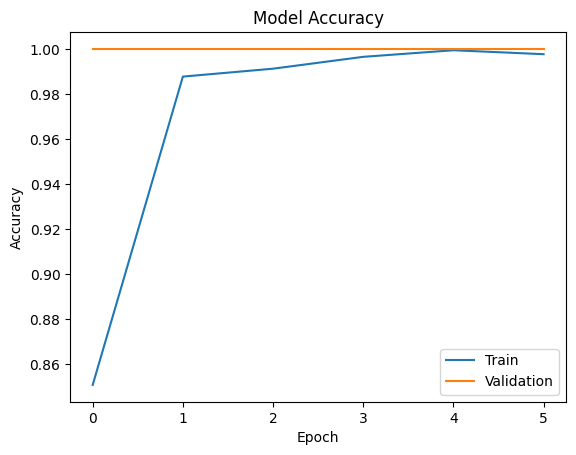

In [18]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

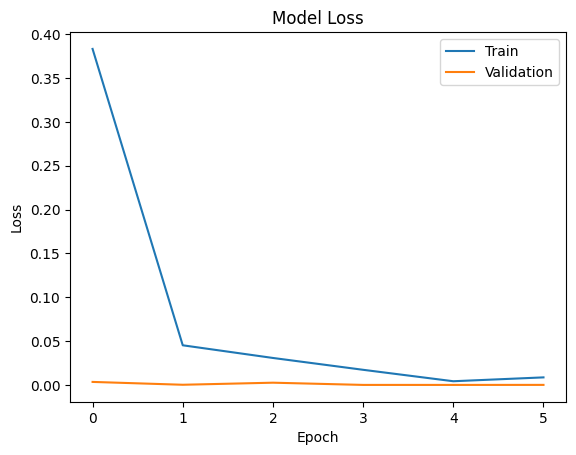

In [19]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

## Konversi Model

In [20]:
model.export("saved_model")

INFO:tensorflow:Assets written to: saved_model/assets


INFO:tensorflow:Assets written to: saved_model/assets


Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  133201529676496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133201529677456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133201529677072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133201529679568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133205208014992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133201529680528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133201529679952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133201529680144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133201529680336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133201529681488: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [21]:
converter = tf.lite.TFLiteConverter.from_saved_model(
    "saved_model"
)

tflite_model = converter.convert()

with open("model.tflite", "wb") as f:
    f.write(tflite_model)

print("Model TFLite berhasil disimpan.")

Model TFLite berhasil disimpan.


W0000 00:00:1778511089.272782      57 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778511089.272838      57 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1778511089.279542      57 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


In [22]:
labels = list(train_generator.class_indices.keys())

with open("label.txt", "w") as f:
    for label in labels:
        f.write(label + "\n")

print("Label berhasil disimpan.")

Label berhasil disimpan.


In [23]:
!pip install tensorflowjs

INFO: pip is looking at multiple versions of wheel to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 918.8 kB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 1.5 MB/s eta 0:00:0000:01
  Attempting uninstall: wheel
    Found existing installation: wheel 0.46.3
    Uninstalling wheel-0.46.3:
      Successfully uninstalled wheel-0.46.3
  Attempting uninstall: packaging
    Found existing installation: packaging 26.0
    Uninstalling packaging-26.0:
      Successfully uninstalled packaging-26.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires 

In [24]:
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    saved_model \
    tfjs_model

2026-05-11 14:51:36.277271: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778511096.292883     313 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778511096.297784     313 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778511096.310030     313 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778511096.310071     313 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778511096.310076     313 computation_placer.cc:177] computation placer alr

## Inference (Optional)

In [25]:
from tensorflow.keras.preprocessing import image

img_path = '/kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360/Test/Banana 1/102_100.jpg'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Predicted Class: Banana 1


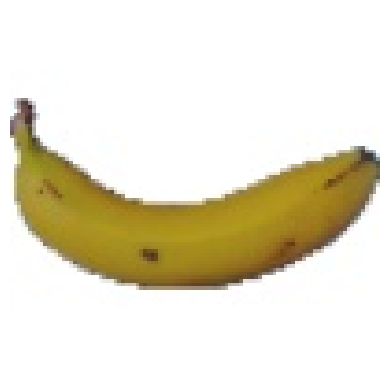

In [26]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img = image.load_img(
    img_path,
    target_size=(100,100)
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

prediction = model.predict(img_array)

predicted_class = labels[np.argmax(prediction)]

print("Predicted Class:", predicted_class)

plt.imshow(img)
plt.axis('off')
plt.show()

In [27]:
import shutil

shutil.rmtree('/kaggle/working/dataset_split')

In [28]:
import os

submission_dir = '/kaggle/working/submission'

os.makedirs(submission_dir, exist_ok=True)

In [29]:
import shutil

shutil.copy('model.tflite', submission_dir)

shutil.copy('label.txt', submission_dir)

shutil.copytree(
    'saved_model',
    os.path.join(submission_dir, 'saved_model')
)

shutil.copytree(
    'tfjs_model',
    os.path.join(submission_dir, 'tfjs_model')
)

'/kaggle/working/submission/tfjs_model'

In [30]:
readme_text = """
# Fruits-360 Image Classification

Project klasifikasi gambar buah menggunakan CNN TensorFlow.

## Dataset
Fruits-360 Dataset

## Kelas
- Apple Red 1
- Banana 1
- Orange 1
- Strawberry 1
- Pineapple 1

## Arsitektur
- Sequential
- Conv2D
- MaxPooling2D
- Dense
- Dropout

## Format Model
- SavedModel
- TensorFlow Lite
- TensorFlow.js
"""

with open(
    os.path.join(submission_dir, 'README.md'),
    'w'
) as f:
    f.write(readme_text)

In [31]:
requirements = """
tensorflow
numpy
matplotlib
scikit-learn
tensorflowjs
"""

with open(
    os.path.join(submission_dir, 'requirements.txt'),
    'w'
) as f:
    f.write(requirements)

In [32]:
shutil.make_archive(
    '/kaggle/working/submission',
    'zip',
    submission_dir
)

'/kaggle/working/submission.zip'

In [33]:
from IPython.display import FileLink

FileLink('/kaggle/working/submission.zip')

/kaggle/working/submission.zip